In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from scipy.stats import randint, uniform
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.sparse
from pygam import LinearGAM, s, f

In [40]:
df = pd.read_csv("data/movie_data_encoded.csv")

In [41]:
def error_analysis(y_true, y_pred, X_data):
    residuals = y_true - y_pred
    error_df = X_data.assign(
        true_revenue=y_true / 1e6,
        pred_revenue=y_pred / 1e6,
        residual=residuals / 1e6,
        pct_error=residuals / y_true
    )

    # Top 5 underestimations (model predicted too low)
    print("Top 5 Underestimations:")
    top_underestimates = error_df.nlargest(5, 'residual')
    display(top_underestimates)

    # Top 5 overestimations (model predicted too high)
    print("\nTop 5 Overestimations:")
    top_overestimates = error_df.nsmallest(5, 'residual')
    display(top_overestimates)

    return error_df, top_underestimates, top_overestimates

def generate_anova_table(X, y, model):
    # Add constant term for intercept
    X = sm.add_constant(X)

    # Fit the model
    model_fitted = sm.OLS(y, X).fit()

    # Generate the ANOVA table
    anova_results = anova_lm(model_fitted)

    # Get t-statistics and p-values
    t_stats = model_fitted.tvalues
    p_values = model_fitted.pvalues

    # Combine all the stats into one DataFrame
    summary = pd.DataFrame({
        'Coefficient': model_fitted.params,
        't-statistic': t_stats,
        'p-value': p_values
    })

    # Adding the ANOVA summary to the table (e.g., sum of squares)
    summary = summary.append(anova_results.iloc[:, 0], ignore_index=False)
    
    print(model_fitted.summary())  # Prints the model summary with all the stats
    return summary

def plot_residual_diagnostics(y_true, y_pred):
    residuals = y_true - y_pred
    standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Residuals vs Fitted
    axs[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axs[0, 0].axhline(0, color='red', linestyle='--')
    axs[0, 0].set_title('Residuals vs Fitted')
    axs[0, 0].set_xlabel('Fitted Values')
    axs[0, 0].set_ylabel('Residuals')

    # Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title('Normal Q-Q Plot')

    # Histogram of Residuals
    sns.histplot(residuals, bins=30, kde=True, ax=axs[1, 0])
    axs[1, 0].set_title('Histogram of Residuals')

    # Residuals vs Order
    axs[1, 1].plot(residuals, marker='o', linestyle='', alpha=0.6)
    axs[1, 1].axhline(0, color='red', linestyle='--')
    axs[1, 1].set_title('Residuals vs Observation Order')
    axs[1, 1].set_xlabel('Observation Order')
    axs[1, 1].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()

def anova(y_true, y_pred, n_predictors=1, alpha=0.05, group_col=None):
    """
    Generate regression evaluation metrics with proper formatting and scaling.
    
    Parameters:
    y_true (array-like): True values (in original units)
    y_pred (array-like): Predicted values (in original units)
    n_predictors (int): Number of predictors in the model
    alpha (float): Significance level for confidence intervals
    group_col (array-like): Grouping variable for lack-of-fit test
    
    Returns:
    dict: Dictionary containing formatted DataFrames
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_true - y_pred
    
    # Basic metrics
    n = len(y_true)
    ss_total = ((y_true - y_true.mean())**2).sum()
    ss_reg = ((y_pred - y_true.mean())**2).sum()
    ss_res = (residuals**2).sum()
    
    # Clip R-squared between 0 and 1
    r_squared = max(0, min(1, ss_reg / ss_total)) if ss_total != 0 else 0
    adj_r_squared = 1 - (ss_res/(n - n_predictors - 1)) / (ss_total/(n - 1)) if ss_total != 0 else 0
    adj_r_squared = max(0, min(1, adj_r_squared))
    
    # Scale metrics to millions
    scale = 1e6  # Scale to millions
    rmse = np.sqrt(ss_res/n) / scale
    mae = np.mean(np.abs(residuals)) / scale
    
    # Degrees of freedom
    df_total = n - 1
    df_reg = n_predictors
    df_res = n - n_predictors - 1
    
    # F-statistic calculations
    ms_reg = ss_reg / df_reg if df_reg != 0 else 0
    ms_res = ss_res / df_res if df_res != 0 else 0
    f_stat = ms_reg / ms_res if ms_res != 0 else 0
    p_value = stats.f.sf(f_stat, df_reg, df_res) if ms_res != 0 else 1
    
    # Formatting function for large numbers
    def format_num(x, scale=1, decimals=3):
        if x == 0:
            return "0"
        scaled = x / scale
        if abs(scaled) >= 1e3 or abs(scaled) < 0.01:
            return f"{scaled:.{decimals}e}"
        return f"{scaled:,.{decimals}f}"
    
    # Model statistics table
    model_stats = pd.DataFrame({
        'Metric': ['R-squared', 'Adjusted R-squared', 
                  f'RMSE (M)', f'MAE (M)', 
                  'F-statistic', 'p-value'],
        'Value': [
            f"{r_squared:.3f}",
            f"{adj_r_squared:.3f}",
            f"{rmse:.3f}",
            f"{mae:.3f}",
            format_num(f_stat, decimals=3),
            f"{p_value:.3e}" if p_value < 0.001 else f"{p_value:.3f}"
        ]
    })
    
    # ANOVA table formatting
    anova_table = pd.DataFrame({
        'Source': ['Regression', 'Residual', 'Total'],
        'SS (M²)': [
            format_num(ss_reg, scale=1e12),  # Convert to (millions)^2
            format_num(ss_res, scale=1e12),
            format_num(ss_total, scale=1e12)
        ],
        'DF': [df_reg, df_res, df_total],
        'MS (M²)': [
            format_num(ms_reg, scale=1e12),
            format_num(ms_res, scale=1e12),
            np.nan
        ],
        'F': [
            format_num(f_stat, decimals=3),
            np.nan,
            np.nan
        ],
        'p-value': [
            f"{p_value:.3e}" if p_value < 0.001 else f"{p_value:.3f}",
            np.nan,
            np.nan
        ]
    }).set_index('Source')
    
    # Lack-of-fit test formatting
    lack_of_fit = None
    if group_col is not None:
        df = pd.DataFrame({'y_true': y_true, 'group': group_col})
        grouped = df.groupby('group')
        
        # Pure error calculation
        ss_pe = 0
        df_pe = 0
        for name, group in grouped:
            if len(group) > 1:
                ss_pe += ((group['y_true'] - group['y_true'].mean())**2).sum()
                df_pe += len(group) - 1
        
        # Lack-of-fit calculation
        if df_pe > 0:
            ss_lof = ss_res - ss_pe
            df_lof = df_res - df_pe
            if df_lof > 0:
                ms_lof = ss_lof / df_lof
                ms_pe = ss_pe / df_pe
                f_lof = ms_lof / ms_pe
                p_lof = stats.f.sf(f_lof, df_lof, df_pe)
                
                lack_of_fit = pd.DataFrame({
                    'Source': ['Lack-of-Fit', 'Pure Error', 'Total Error'],
                    'SS': [ss_lof, ss_pe, ss_res],
                    'DF': [df_lof, df_pe, df_res],
                    'MS': [ms_lof, ms_pe, np.nan],
                    'F': [f_lof, np.nan, np.nan],
                    'p-value': [p_lof, np.nan, np.nan]
                }).set_index('Source')
    
    return {
        'model_statistics': model_stats,
        'anova_table': anova_table,
        'lack_of_fit_test': lack_of_fit
    }



def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR

        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
    return df_clean

In [42]:
df.columns

Index(['Unnamed: 0', 'name', 'genres', 'directors', 'writers', 'averageRating',
       'numVotes', 'actors', 'original_language', 'production_companies',
       'release_date', 'budget', 'revenue', 'runtime', 'status', 'keywords',
       'trailer_views', 'trailer_likes', 'titleType_movie',
       'titleType_tvMovie', 'director_score', 'writer_score', 'actor_score',
       'star_score', 'is_documentary', 'genres_Action', 'genres_Adult',
       'genres_Adventure', 'genres_Animation', 'genres_Biography',
       'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama',
       'genres_Family', 'genres_Fantasy', 'genres_Film-Noir', 'genres_History',
       'genres_Horror', 'genres_Music', 'genres_Musical', 'genres_Mystery',
       'genres_Romance', 'genres_Sci-Fi', 'genres_Sport', 'genres_Thriller',
       'genres_War', 'genres_Western', 'is_holiday_release',
       'is_competitive_month', 'production_popular', 'lang_en', 'lang_fr',
       'lang_es', 'lang_hi', 'lang_ja', 'lang_

In [43]:
df_clean = df[(df['trailer_views'] >= 0) & (df['trailer_likes'] >= 0)].copy() # Remove negative values
#df_clean = handle_outliers(df_clean, df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()) # Remove outlier

df_clean['release_year'] = pd.to_datetime(df_clean['release_date']).dt.year # Add temporal feature because there's an trend in residual versus observation order
df_clean['release_year_centered'] = df_clean['release_year'] - df_clean['release_year'].mean() 

df_sorted_asc = df_clean.sort_values(by='release_date')

important_feature_based_on_domain_expertise = ['budget', 'actor_score', 'star_score', 'trailer_views', 'trailer_likes', 'revenue', 'release_year', 'release_year_centered']
test = df_sorted_asc[important_feature_based_on_domain_expertise].copy()

test['revenue'] = np.log1p(test['revenue'])
test['trailer_likes_log'] = np.log1p(test['trailer_likes'])
test['trailer_views_log'] = np.log1p(test['trailer_views'])
test['budget_log'] = np.log1p(test['budget'])
test['actor_score_log'] = np.log1p(test['actor_score'])
test['budget_actor_interaction'] = test['budget_log'] * test['actor_score_log']

test = test[['trailer_views_log', 'trailer_likes_log', 'budget_log', 'budget_actor_interaction',
              'release_year_centered', 'revenue']]


In [44]:
df_clean['revenue'].describe() /1e6

count      0.010487
mean      27.424659
std       44.154261
min        0.000001
25%        2.330829
50%       13.464154
75%       35.085382
max      908.011354
Name: revenue, dtype: float64

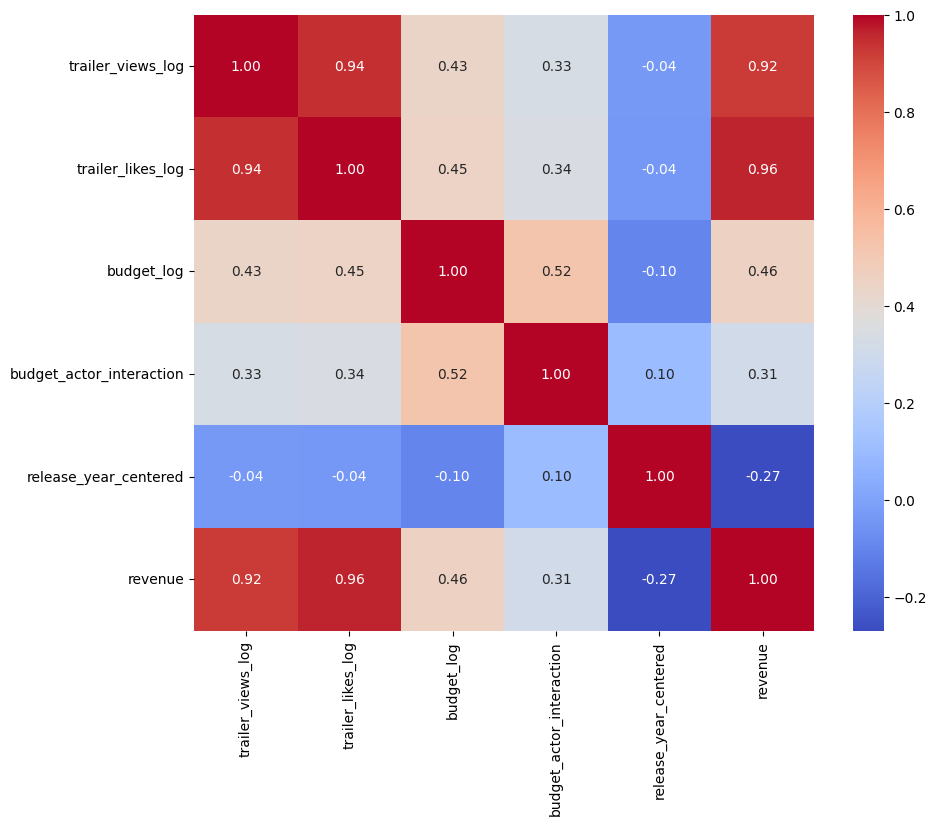

In [45]:
# Calculate the correlation matrix
corr_matrix = test.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [46]:
test.shape

(10487, 6)

In [47]:
X = test.drop('revenue', axis=1)
X.drop('trailer_views_log', axis=1, inplace=True) # drop due to muticolinearity
y = df_sorted_asc['revenue']

In [48]:
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(len(X.columns))]

In [50]:
vif

,feature,VIF
0,trailer_likes_log,3.710821
1,budget_log,4.829055
2,budget_actor_interaction,2.066637
3,release_year_centered,1.040525


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
y_train_log = np.log1p(y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
y_test.describe() / 1e6

count      0.002098
mean      15.061314
std       24.192728
min        0.000001
25%        0.680149
50%        6.348052
75%       19.532990
max      343.488835
Name: revenue, dtype: float64

In [52]:
X_train.shape == X.shape

False

In [53]:
X_train

,trailer_likes_log,budget_log,budget_actor_interaction,release_year_centered
0,13.583632,18.059285,0.000000,-87.056355
4,10.681511,13.058981,0.000000,-86.056355
2,15.082366,14.948792,16.422927,-86.056355
3,10.606828,13.194966,0.000000,-86.056355
5,10.517514,13.455893,0.000000,-86.056355
...,...,...,...,...
9839,15.478698,0.000000,0.000000,13.943645
9014,13.743604,16.175222,0.000000,13.943645
10175,11.187573,13.045961,0.000000,13.943645
8724,13.123232,17.314657,19.022095,13.943645


In [54]:
X_train

,trailer_likes_log,budget_log,budget_actor_interaction,release_year_centered
0,13.583632,18.059285,0.000000,-87.056355
4,10.681511,13.058981,0.000000,-86.056355
2,15.082366,14.948792,16.422927,-86.056355
3,10.606828,13.194966,0.000000,-86.056355
5,10.517514,13.455893,0.000000,-86.056355
...,...,...,...,...
9839,15.478698,0.000000,0.000000,13.943645
9014,13.743604,16.175222,0.000000,13.943645
10175,11.187573,13.045961,0.000000,13.943645
8724,13.123232,17.314657,19.022095,13.943645


In [55]:
X_test

,trailer_likes_log,budget_log,budget_actor_interaction,release_year_centered
10251,9.120995,0.000000,0.000000,14.943645
9525,16.395626,16.385830,0.000000,14.943645
9516,15.171438,16.375779,0.000000,14.943645
4734,14.844550,15.731903,0.000000,14.943645
10353,4.823714,0.000000,0.000000,14.943645
...,...,...,...,...
8840,15.210592,17.938923,32.142235,21.943645
9024,15.944859,20.136147,27.914628,21.943645
7058,15.050052,18.226605,35.467336,21.943645
7362,15.874193,17.245776,0.000000,21.943645


In [69]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train_cv, np.log1p(y_train_cv))
    y_pred_cv = np.expm1(model.predict(X_test_cv))

    rmse_cv = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv)) / 1e6
    print(f"Fold RMSE: {rmse_cv:.2f} Millions")


Fold RMSE: 16.87 Millions
Fold RMSE: 9.10 Millions
Fold RMSE: 8.52 Millions
Fold RMSE: 7.87 Millions
Fold RMSE: 8.07 Millions


In [70]:
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred)) / 1e6
print(f"RMSE: {rmse:.2f} M, MAE: {mae:.2f} M")
print(f"R-squared: {round(r2, 2)}")

RMSE: 8.09 M, MAE: 3.48 M
R-squared: 0.89


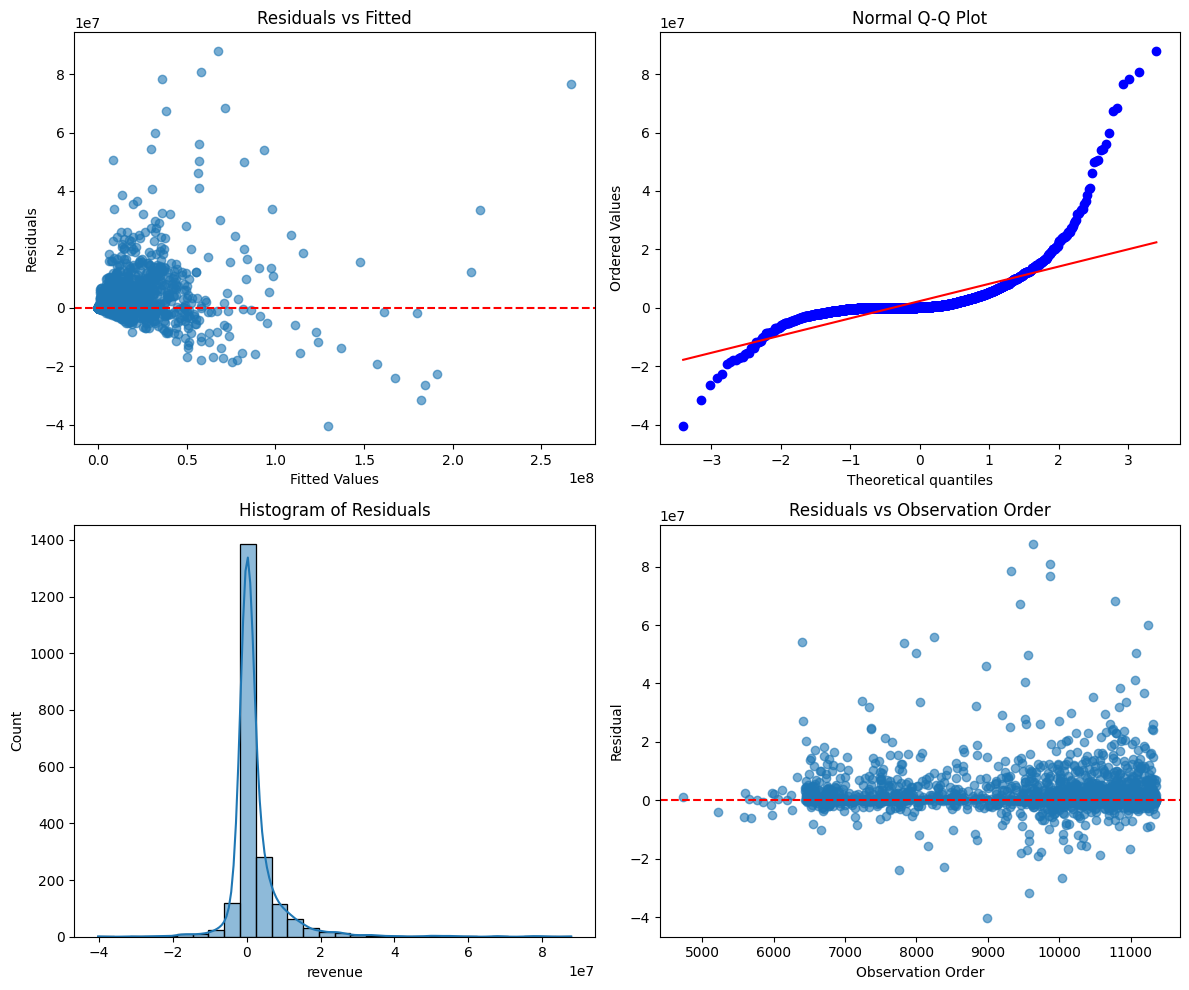

In [67]:
plot_residual_diagnostics(y_test, y_pred)

In [59]:
#anova = anova(y_test, y_pred, n_predictors=7, alpha=0.05)
#nova

In [72]:
residuals, under, over = error_analysis(y_test, y_pred, X_test)

Top 5 Underestimations:


,trailer_likes_log,budget_log,budget_actor_interaction,release_year_centered,true_revenue,pred_revenue,residual,pct_error
9632,16.773370,19.336351,21.243153,16.943645,155.254282,74.873547,80.380735,0.517736
9870,16.655237,19.043956,37.057828,17.943645,138.823851,69.286904,69.536947,0.500901
10782,17.016250,18.449749,20.269120,21.943645,139.571155,70.677575,68.893581,0.493609
9330,16.052114,19.604705,35.126917,14.943645,114.184371,53.236675,60.947695,0.533766
7820,17.290222,18.821312,43.337673,21.943645,147.694148,88.128473,59.565675,0.403304



Top 5 Overestimations:


,trailer_likes_log,budget_log,budget_actor_interaction,release_year_centered,true_revenue,pred_revenue,residual,pct_error
8983,17.548167,19.483365,40.514519,19.943645,89.619988,139.901664,-50.281676,-0.561054
8044,18.101774,20.016145,21.989982,20.943645,248.701369,291.650668,-42.949299,-0.172694
10046,17.761904,19.583626,40.723005,15.943645,158.176081,188.382191,-30.206110,-0.190965
9580,17.714639,19.604705,31.552556,14.943645,150.741139,178.937501,-28.196362,-0.187052
9024,15.944859,20.136147,27.914628,21.943645,23.521224,49.377920,-25.856696,-1.099292


In [73]:
check = df_clean.loc[over.index[0]]
print(check)

Unnamed: 0                                                            9925
name                                                        No Time to Die
genres                                           Action,Adventure,Thriller
directors                                               Cary Joji Fukunaga
writers                  Neal Purvis,Robert Wade,Cary Joji Fukunaga,Pho...
                                               ...                        
has_trailer                                                            1.0
has_keywords                                                             1
keyword_embedding                                                 0.423418
release_year                                                          2021
release_year_centered                                            19.943645
Name: 8983, Length: 62, dtype: object


In [ ]:
EL_tune = ElasticNet()

search_space = {
    'alpha': np.logspace(-4, 2, 50),  # Regularization strength (L1 + L2)
    'l1_ratio': np.linspace(0, 1, 21),  # Balance between L1 (lasso) and L2 (ridge)
}

grid_search = GridSearchCV(
    estimator=EL_tune,
    param_grid=search_space,
    cv=KFold(n_splits=5),
    scoring='neg_mean_squared_error',
    n_jobs=-1  # Optional: speeds things up if you have multiple cores
)

grid_search.fit(X_train, y_train_log)

In [ ]:
model = ElasticNet(alpha=np.float64(0.00030888435964774815),
           l1_ratio=np.float64(0.9500000000000001), random_state=42)
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
mae = np.mean(np.abs(y_test - y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f} M, MAE: {mae:.2f} M")
print(f"R-squared: {round(r2, 2)}")

RMSE: 8.09 Millions
R-squared: 0.89


In [71]:
np.int = int
scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())

gam = LinearGAM(
    s(0) +  # trailer_likes_log
    s(1) +  # budget_log
    s(2) +  # budget_actor_interaction
    s(3)    # release_year_centered
).fit(X_train, y_train_log)

y_pred_log = gam.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
mae = np.mean(np.abs(y_test - y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f} M, MAE: {mae:.2f} M")
print(f"R-squared: {round(r2, 2)}")

RMSE: 7.33 M, MAE: 3.27 M
R-squared: 0.91


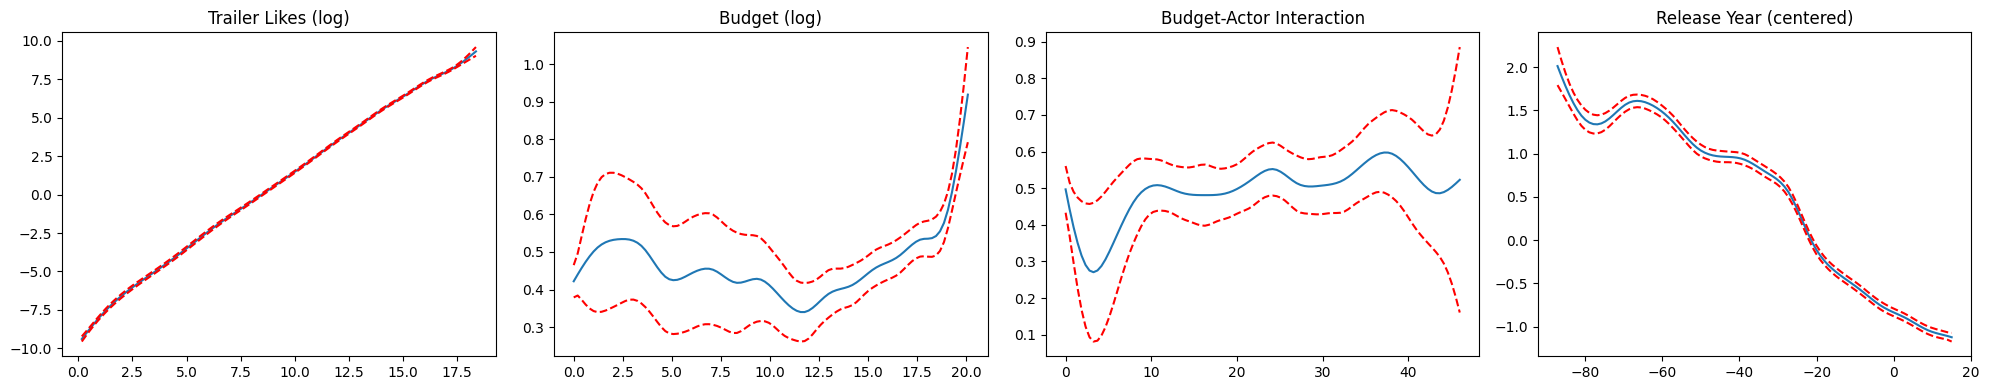

In [65]:
scipy.sparse.csc_matrix.A = property(lambda self: self.toarray())
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

titles = [
    "Trailer Likes (log)", 
    "Budget (log)", 
    "Budget-Actor Interaction", 
    "Release Year (centered)"
]

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()